# Estimación de la edad cerebral a partir del EEG del sueño

**Análisis de datos — Sleep-EDF Database Expanded, subconjunto Sleep Cassette**

Universidad de los Andes — Maestría en Inteligencia Artificial

Este análisis es complementario al de clasificación de estadios de sueño. El objetivo aquí no es
predecir la etapa de sueño, sino **estimar la edad del sujeto a partir de su EEG durante el sueño**,
y a partir de esa estimación calcular el *Brain Age Index* (BAI), definido como la diferencia entre
la edad estimada y la edad cronológica. El BAI es la medida que el sistema final usará para priorizar
sujetos con mayor divergencia.

Referencia: Sun et al. (2019), *Brain age from the electroencephalogram of sleep*.

# 1. Lectura de datos

## 1.1 Librerías y configuración

Se trabaja con el canal **EEG Fpz-Cz**, por ser el canal de referencia en la literatura sobre esta
base de datos y uno de los que efectivamente se registró a 100 Hz.

In [1]:
import glob, os, warnings

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from scipy import stats
from scipy.signal import welch
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

mne.set_log_level("WARNING")
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Guarda cada figura de plotly en dos formatos: interactivo (Jupyter) y PNG (GitHub, que no ejecuta JS)
pio.renderers.default = "plotly_mimetype+png"

# Los datos pueden estar en la carpeta compartida del repositorio (dvc pull) o en la carpeta local
RAIZ_DATOS = next(ruta for ruta in ("../../Data", "data") if os.path.isdir(ruta + "/sleep-cassette"))
DATA_DIR = RAIZ_DATOS + "/sleep-cassette"
SUBJECTS_XLS = RAIZ_DATOS + "/SC-subjects.xls"
CANAL = "EEG Fpz-Cz"
EPOCA_S = 30  # duración estándar de una época de sueño

ETAPAS = {"Sleep stage W": "W", "Sleep stage 1": "N1", "Sleep stage 2": "N2", "Sleep stage 3": "N3",
          "Sleep stage 4": "N3", "Sleep stage R": "REM", "Movement time": "M", "Sleep stage ?": "?"}
NREM = {"Sleep stage 2", "Sleep stage 3", "Sleep stage 4"}
DORMIDO = {"N1", "N2", "N3", "REM"}

# Bandas de frecuencia clásicas del EEG
BANDAS = {"delta": (0.5, 4), "theta": (4, 8), "alpha": (8, 12),
          "husos": (12, 16), "beta": (16, 30)}
GRUPOS = {"25-45 años": (25, 45, "#2a78d6"), "46-69 años": (46, 69, "#1baf7a"),
          "70+ años": (70, 120, "#eb6834")}

print("Datos leídos desde:", RAIZ_DATOS)

Datos leídos desde: data


## 1.2 Inventario de registros y metadatos

Cada noche está compuesta por un registro de señal (`*-PSG.edf`) y un hipnograma de anotaciones
(`*-Hypnogram.edf`) que comparten prefijo. La edad de cada sujeto —la variable objetivo de este
análisis— se encuentra en `SC-subjects.xls`.

In [2]:
psg_files = sorted(glob.glob(DATA_DIR + "/*-PSG.edf"))
hyp_files = sorted(glob.glob(DATA_DIR + "/*-Hypnogram.edf"))

subjects = pd.read_excel(SUBJECTS_XLS).rename(columns={"sex (F=1)": "sex_code"})
subjects["sex"] = subjects["sex_code"].map({1: "F", 2: "M"})

# Clave sujeto-noche a partir del nombre: SC4001E0-PSG.edf -> sujeto 00, noche 1
claves = [(int(os.path.basename(p)[3:5]), int(os.path.basename(p)[5])) for p in psg_files]
registros = pd.DataFrame(claves, columns=["subject", "night"]).assign(psg=psg_files, hyp=hyp_files)
registros = registros.merge(subjects[["subject", "night", "age", "sex"]], on=["subject", "night"])

print("Registros PSG:", len(psg_files), "| Hipnogramas:", len(hyp_files))
print("Registros con edad conocida:", registros["age"].notna().sum(), "de", len(registros))
registros.head()

Registros PSG: 153 | Hipnogramas: 153
Registros con edad conocida: 153 de 153


,subject,night,psg,hyp,age,sex
0,0,1,data/sleep-cassette/SC4001E0-PSG.edf,data/sleep-cassette/SC4001EC-Hypnogram.edf,33,F
1,0,2,data/sleep-cassette/SC4002E0-PSG.edf,data/sleep-cassette/SC4002EC-Hypnogram.edf,33,F
2,1,1,data/sleep-cassette/SC4011E0-PSG.edf,data/sleep-cassette/SC4011EH-Hypnogram.edf,33,F
3,1,2,data/sleep-cassette/SC4012E0-PSG.edf,data/sleep-cassette/SC4012EC-Hypnogram.edf,33,F
4,2,1,data/sleep-cassette/SC4021E0-PSG.edf,data/sleep-cassette/SC4021EH-Hypnogram.edf,26,F


# 2. La variable objetivo: la edad

A diferencia de la clasificación de estadios —donde la etiqueta se obtiene del hipnograma, época por
época— aquí la etiqueta es **una sola por sujeto**: su edad. Esto reduce drásticamente el tamaño
efectivo de la muestra: no se dispone de 153 000 épocas etiquetadas, sino de **78 edades**.

Por ello, lo primero es verificar si esas 78 edades cubren un rango suficiente y están distribuidas
de forma utilizable.

Personas: 78 | {'F': 41, 'M': 37}
Edad: 25-101 años (media 58.8, mediana 57, desv. 22.1)
  25-45 años   n = 20  (26 %)
  46-69 años   n = 34  (44 %)
  70+ años     n = 24  (31 %)


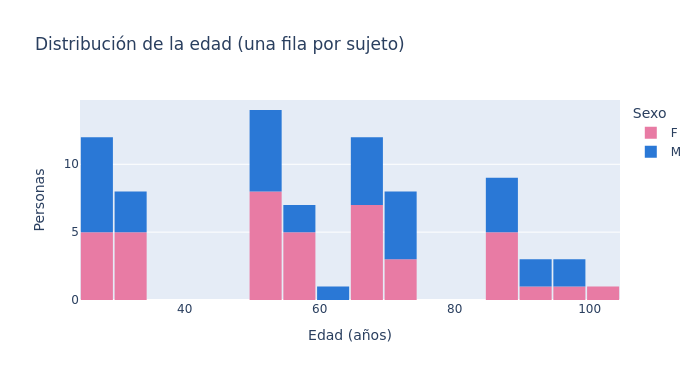

In [3]:
personas = registros.drop_duplicates("subject")

print(f"Personas: {len(personas)} | {personas['sex'].value_counts().to_dict()}")
print(f"Edad: {personas['age'].min()}-{personas['age'].max()} años "
      f"(media {personas['age'].mean():.1f}, mediana {personas['age'].median():.0f}, "
      f"desv. {personas['age'].std():.1f})")

for etiqueta, (desde, hasta, _) in GRUPOS.items():
    n = ((personas["age"] >= desde) & (personas["age"] <= hasta)).sum()
    print(f"  {etiqueta:12s} n = {n:2d}  ({n / len(personas) * 100:.0f} %)")

px.histogram(personas, x="age", nbins=20, color="sex", title="Distribución de la edad (una fila por sujeto)",
             labels={"age": "Edad (años)", "sex": "Sexo"}, color_discrete_map={"F": "#e87ba4", "M": "#2a78d6"}
             ).update_layout(height=380, yaxis_title="Personas", bargap=0.05).show()

El rango de edad es amplio (25 a 101 años), lo cual es favorable: un modelo de edad cerebral
necesita variabilidad en la variable objetivo para poder aprender algo. Conviene revisar, sin
embargo, si la distribución es uniforme o si hay concentraciones que puedan sesgar el modelo hacia
determinadas franjas.

Tramo de edad  Personas
     (20, 30]        13
     (30, 40]         7
     (40, 50]         2
     (50, 60]        20
     (60, 70]        13
     (70, 80]         7
     (80, 90]        10
    (90, 100]         5


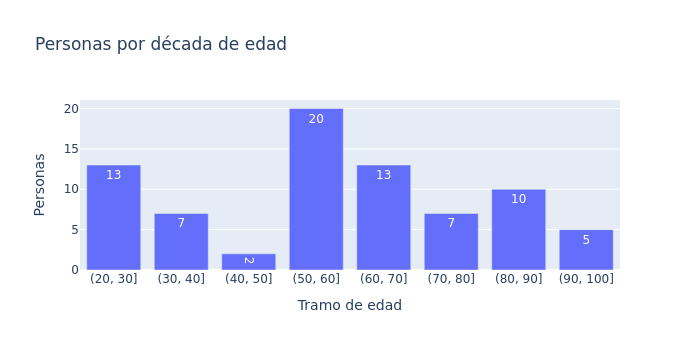

In [4]:
# Comprobación de uniformidad: ¿está la edad repartida o concentrada en pocos tramos?
tramos = pd.cut(personas["age"], bins=range(20, 110, 10))
conteo = tramos.value_counts().sort_index().rename_axis("Tramo de edad").reset_index(name="Personas")
conteo["Tramo de edad"] = conteo["Tramo de edad"].astype(str)
print(conteo.to_string(index=False))

px.bar(conteo, x="Tramo de edad", y="Personas", text="Personas",
       title="Personas por década de edad").update_layout(height=350).show()

# 3. Arquitectura del sueño

Antes de mirar la señal conviene describir la **estructura** de cada noche: cuánto durmió el sujeto,
qué proporción del tiempo pasó en cada estadio y cuánto tiempo estuvo despierto tras haberse dormido.
Estas variables son conocidas por su variación con la edad y constituyen el primer conjunto de
características candidatas para estimar la edad cerebral.

## 3.1 Delimitación del periodo de sueño

Los registros del subconjunto Sleep Cassette son ambulatorios y abarcan un ciclo día-noche completo,
por lo que duran alrededor de **20 horas**. La mayor parte de ese tiempo es vigilia diurna, ajena al
sueño. Calcular porcentajes sobre el registro completo produciría cifras carentes de sentido, de modo
que se delimita el periodo de sueño entre la primera y la última época no clasificada como vigilia.

In [5]:
def arquitectura_de_la_noche(ruta_hyp):
    """Métricas estructurales de una noche, calculadas sobre el periodo de sueño delimitado."""
    ann = mne.read_annotations(ruta_hyp)
    hip = pd.DataFrame({"inicio": ann.onset, "duracion": ann.duration,
                        "etapa": [ETAPAS.get(d, "?") for d in ann.description]})

    dormido = hip[hip["etapa"].isin(DORMIDO)]
    if dormido.empty:
        return None

    # Periodo de sueño: del primer al último instante en que el sujeto no está despierto
    inicio = dormido["inicio"].iloc[0]
    fin = (dormido["inicio"] + dormido["duracion"]).iloc[-1]
    periodo = hip[(hip["inicio"] + hip["duracion"] > inicio) & (hip["inicio"] < fin)].copy()

    # Recorte de los segmentos que sobresalen del periodo
    periodo["duracion"] = (np.minimum(periodo["inicio"] + periodo["duracion"], fin)
                           - np.maximum(periodo["inicio"], inicio))

    por_etapa = periodo.groupby("etapa")["duracion"].sum()
    tst = por_etapa.reindex(list(DORMIDO)).fillna(0).sum()   # tiempo total de sueño
    en_cama = fin - inicio

    fila = {"duracion_registro_h": (hip["inicio"] + hip["duracion"]).iloc[-1] / 3600,
            "periodo_sueno_h": en_cama / 3600,
            "tst_h": tst / 3600,
            "eficiencia": tst / en_cama if en_cama else np.nan,
            "waso_min": por_etapa.get("W", 0) / 60,          # vigilia tras el inicio del sueño
            "latencia_rem_min": ((periodo[periodo["etapa"] == "REM"]["inicio"].min() - inicio) / 60
                                 if (periodo["etapa"] == "REM").any() else np.nan)}
    for etapa in ("N1", "N2", "N3", "REM"):
        fila[f"pct_{etapa}"] = por_etapa.get(etapa, 0) / tst * 100 if tst else np.nan
    return fila


arq = pd.DataFrame([arquitectura_de_la_noche(r) for r in registros["hyp"]], index=registros.index)
noches = pd.concat([registros.drop(columns=["psg", "hyp"]), arq], axis=1)

print(f"Duración del registro completo: mediana {noches['duracion_registro_h'].median():.1f} h "
      f"(rango {noches['duracion_registro_h'].min():.1f}-{noches['duracion_registro_h'].max():.1f})")
print(f"Periodo de sueño delimitado:    mediana {noches['periodo_sueno_h'].median():.1f} h")
noches[["subject", "night", "age", "tst_h", "eficiencia", "waso_min",
        "pct_N2", "pct_N3", "pct_REM"]].head()

Duración del registro completo: mediana 24.0 h (rango 24.0-24.0)
Periodo de sueño delimitado:    mediana 8.4 h


,subject,night,age,tst_h,eficiencia,waso_min,pct_N2,pct_N3,pct_REM
0,0,1,33,5.441667,0.905687,34.0,38.284839,33.690658,19.142420
1,0,2,33,7.866667,0.936508,31.5,39.512712,31.461864,22.775424
2,1,1,33,7.883333,0.962360,18.5,59.408034,11.099366,17.970402
3,1,2,33,8.533333,0.960600,21.0,64.453125,9.375000,17.187500
4,2,1,26,7.475000,0.991160,4.0,60.758082,10.590858,18.171683


La diferencia entre ambas cifras confirma lo anterior: el registro dura unas 20 horas, pero el
periodo de sueño ocupa solo una fracción. Cualquier característica calculada sobre la señal debe
restringirse a este periodo; de lo contrario se estaría midiendo vigilia diurna.

## 3.2 Relación entre la arquitectura del sueño y la edad

In [6]:
VARIABLES_ARQ = {"tst_h": "Tiempo total de sueño (h)", "eficiencia": "Eficiencia del sueño",
                 "waso_min": "Vigilia tras inicio del sueño (min)", "pct_N1": "% N1",
                 "pct_N2": "% N2", "pct_N3": "% N3 (sueño profundo)", "pct_REM": "% REM"}

# Se promedian las dos noches de cada sujeto: no son observaciones independientes
por_sujeto = noches.groupby("subject").agg({"age": "first", "sex": "first",
                                            **{v: "mean" for v in VARIABLES_ARQ}}).reset_index()

print(f"Correlación con la edad (n = {len(por_sujeto)} sujetos)\n")
print(f"{'variable':34s} {'r':>7s} {'p':>9s}")
correlaciones = {}
for var, etiqueta in VARIABLES_ARQ.items():
    datos = por_sujeto[[var, "age"]].dropna()
    r, p = stats.pearsonr(datos[var], datos["age"])
    correlaciones[var] = r
    print(f"{etiqueta:34s} {r:+.3f} {p:9.4f}{'  *' if p < 0.05 else ''}")

Correlación con la edad (n = 78 sujetos)

variable                                 r         p
Tiempo total de sueño (h)          -0.063    0.5862
Eficiencia del sueño               -0.615    0.0000  *
Vigilia tras inicio del sueño (min) +0.571    0.0000  *
% N1                               +0.637    0.0000  *
% N2                               -0.008    0.9415
% N3 (sueño profundo)              -0.421    0.0001  *
% REM                              -0.313    0.0053  *


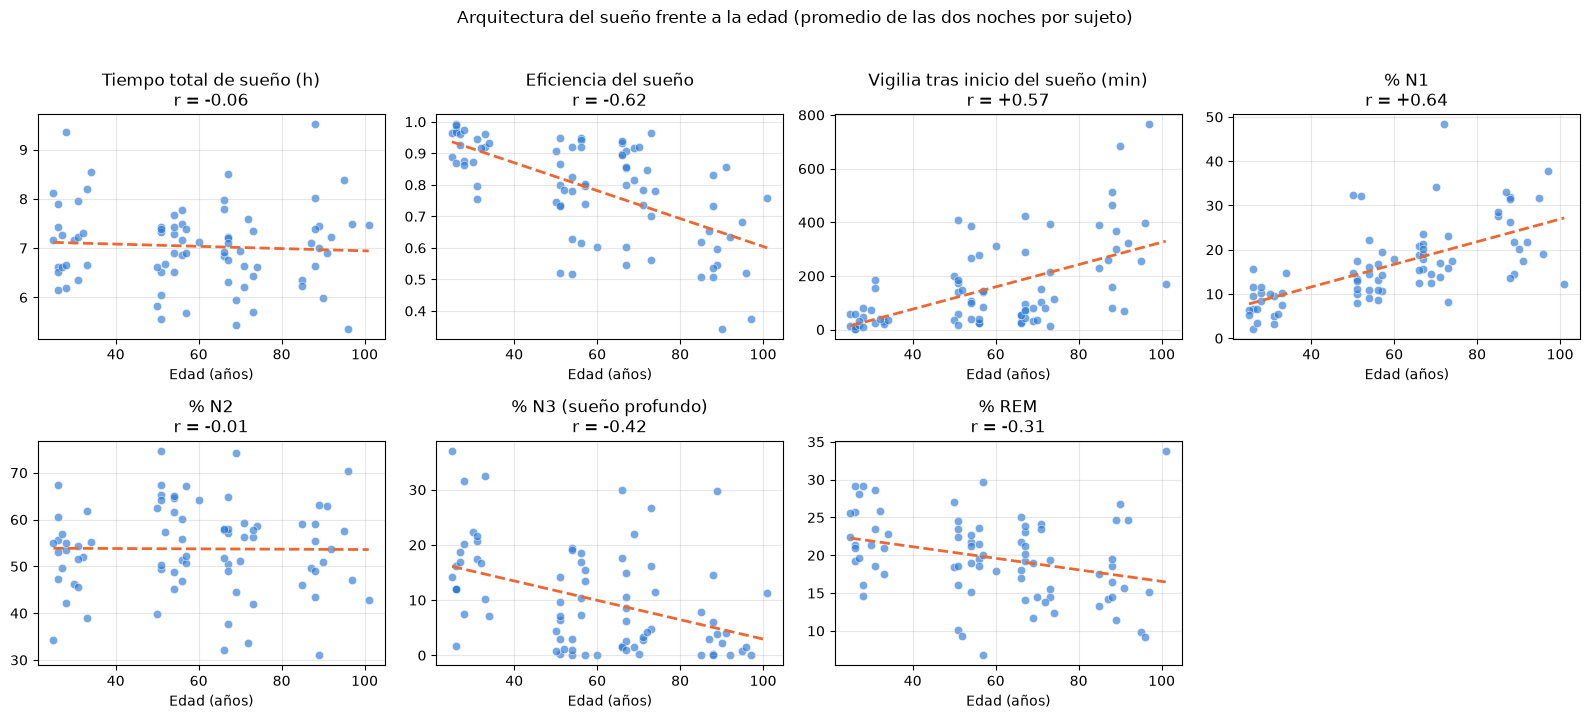

In [7]:
fig, ejes = plt.subplots(2, 4, figsize=(16, 7))
for eje, (var, etiqueta) in zip(ejes.ravel(), VARIABLES_ARQ.items()):
    datos = por_sujeto[[var, "age"]].dropna()
    eje.scatter(datos["age"], datos[var], alpha=0.65, color="#2a78d6",
                edgecolor="white", linewidth=0.5)
    eje.plot(sorted(datos["age"]),
             np.polyval(np.polyfit(datos["age"], datos[var], 1), sorted(datos["age"])),
             "--", color="#eb6834", linewidth=2)
    eje.set(xlabel="Edad (años)", title=f"{etiqueta}\nr = {correlaciones[var]:+.2f}")
    eje.grid(alpha=0.3)
ejes.ravel()[-1].axis("off")

plt.suptitle("Arquitectura del sueño frente a la edad (promedio de las dos noches por sujeto)", y=1.02)
plt.tight_layout()
plt.show()

# 4. Contenido espectral de la señal

Se descompone la señal en sus componentes de frecuencia mediante el método de Welch, restringiendo el
cálculo a épocas de sueño NREM repartidas a lo largo de la noche. De cada noche se toman 30 épocas de
30 segundos, distribuidas uniformemente entre todas las épocas NREM disponibles, y se promedia el
espectro resultante.

Restringir a NREM cumple dos funciones: excluye la vigilia diurna que domina el registro y homogeneiza
la comparación entre sujetos, ya que el espectro depende fuertemente del estadio de sueño.

In [8]:
def espectro_de_la_noche(ruta_psg, ruta_hyp, n_epocas=30):
    """Espectro promedio de n_epocas de sueño NREM repartidas a lo largo de una noche."""
    ann = mne.read_annotations(ruta_hyp)
    registro = mne.io.read_raw_edf(ruta_psg, preload=False)
    frec = registro.info["sfreq"]

    inicios = [onset + EPOCA_S * k
               for onset, duracion, etapa in zip(ann.onset, ann.duration, ann.description)
               if etapa in NREM for k in range(int(duracion // EPOCA_S))]
    if len(inicios) < n_epocas:
        return None, None

    psds = []
    for i in np.linspace(0, len(inicios) - 1, n_epocas).astype(int):
        ini = int(inicios[i] * frec)
        muestras = registro.get_data(picks=[CANAL], start=ini, stop=ini + int(EPOCA_S * frec))[0]
        frecuencias, psd = welch(muestras, fs=frec, nperseg=int(4 * frec))
        psds.append(psd)
    return frecuencias, np.mean(psds, axis=0) * 1e12  # V²/Hz -> µV²/Hz


resultados = [espectro_de_la_noche(p, h) for p, h in zip(registros["psg"], registros["hyp"])]
validos = [i for i, (f, _) in enumerate(resultados) if f is not None]
frecs = resultados[validos[0]][0]
espectros = np.array([resultados[i][1] for i in validos])

print(f"Espectros calculados: {len(espectros)} de {len(registros)} noches")
print(f"Resolución en frecuencia: {frecs[1] - frecs[0]:.2f} Hz | rango 0-{frecs.max():.0f} Hz")

Espectros calculados: 153 de 153 noches
Resolución en frecuencia: 0.25 Hz | rango 0-50 Hz


## 4.1 Espectro promedio por grupo de edad

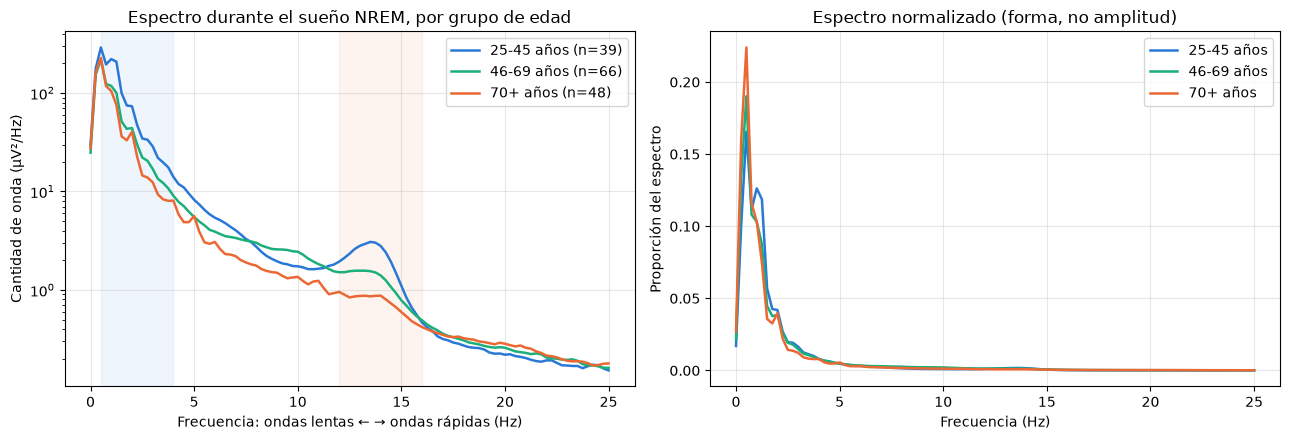

In [9]:
edades_esp = registros.iloc[validos]["age"].values
visible = frecs <= 25

fig, ejes = plt.subplots(1, 2, figsize=(13, 4.5))

for etiqueta, (desde, hasta, color) in GRUPOS.items():
    grupo = (edades_esp >= desde) & (edades_esp <= hasta)
    ejes[0].semilogy(frecs[visible], espectros[grupo][:, visible].mean(axis=0),
                     color=color, linewidth=1.8, label=f"{etiqueta} (n={grupo.sum()})")
ejes[0].axvspan(0.5, 4, alpha=0.07, color="#2a78d6")
ejes[0].axvspan(12, 16, alpha=0.07, color="#eb6834")
ejes[0].set(xlabel="Frecuencia: ondas lentas ← → ondas rápidas (Hz)",
            ylabel="Cantidad de onda (µV²/Hz)",
            title="Espectro durante el sueño NREM, por grupo de edad")
ejes[0].legend()

# Mismo espectro normalizado: aísla el cambio de forma del cambio de amplitud global
for etiqueta, (desde, hasta, color) in GRUPOS.items():
    grupo = (edades_esp >= desde) & (edades_esp <= hasta)
    medio = espectros[grupo][:, visible].mean(axis=0)
    ejes[1].plot(frecs[visible], medio / medio.sum(), color=color, linewidth=1.8, label=etiqueta)
ejes[1].set(xlabel="Frecuencia (Hz)", ylabel="Proporción del espectro",
            title="Espectro normalizado (forma, no amplitud)")
ejes[1].legend()

[eje.grid(alpha=0.3) for eje in ejes]
plt.tight_layout()
plt.show()

El panel izquierdo muestra la amplitud absoluta y el derecho la forma del espectro una vez
eliminada la amplitud global. La distinción importa: una parte de la caída con la edad se debe a la
reducción general de amplitud del EEG (atrofia cortical, cambios en el cráneo), y otra a un cambio
real en la distribución relativa de la actividad entre bandas.

## 4.2 Potencia por banda frente a la edad

In [10]:
# Potencia relativa de cada banda respecto al total 0.5-30 Hz
mascara_total = (frecs >= 0.5) & (frecs <= 30)
total = espectros[:, mascara_total].sum(axis=1)

bandas = pd.DataFrame({"subject": registros.iloc[validos]["subject"].values,
                       "night": registros.iloc[validos]["night"].values,
                       "age": edades_esp,
                       "potencia_total_log": np.log10(total)})
for nombre, (desde, hasta) in BANDAS.items():
    mascara = (frecs >= desde) & (frecs < hasta)
    bandas[f"rel_{nombre}"] = espectros[:, mascara].sum(axis=1) / total

# Frecuencia por debajo de la cual se acumula el 95 % de la potencia
acumulado = np.cumsum(espectros[:, mascara_total], axis=1)
bandas["sef95"] = frecs[mascara_total][np.argmax(acumulado >= 0.95 * acumulado[:, [-1]], axis=1)]

espectral_sujeto = bandas.groupby("subject").mean().reset_index().drop(columns="night")

print(f"Correlación con la edad (n = {len(espectral_sujeto)} sujetos)\n")
print(f"{'característica':24s} {'r':>7s} {'p':>9s}")
for col in [c for c in espectral_sujeto.columns if c not in ("subject", "age")]:
    r, p = stats.pearsonr(espectral_sujeto[col], espectral_sujeto["age"])
    print(f"{col:24s} {r:+.3f} {p:9.4f}{'  *' if p < 0.05 else ''}")

Correlación con la edad (n = 78 sujetos)

característica                 r         p
potencia_total_log       -0.375    0.0007  *
rel_delta                +0.019    0.8675
rel_theta                -0.082    0.4773
rel_alpha                +0.090    0.4309
rel_husos                -0.294    0.0089  *
rel_beta                 +0.398    0.0003  *
sef95                    +0.007    0.9543


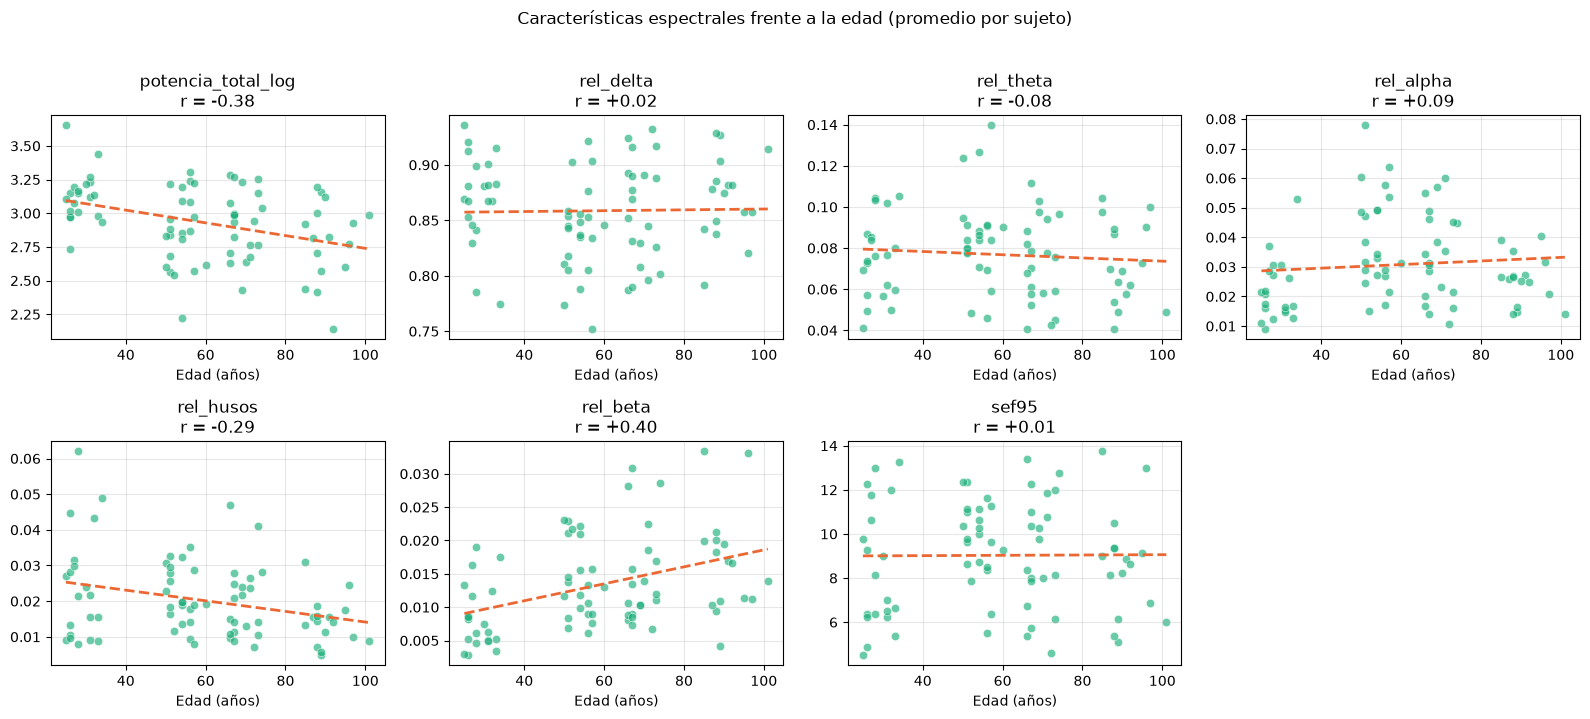

In [11]:
caracteristicas = [c for c in espectral_sujeto.columns if c not in ("subject", "age")]

fig, ejes = plt.subplots(2, 4, figsize=(16, 7))
for eje, col in zip(ejes.ravel(), caracteristicas):
    r, _ = stats.pearsonr(espectral_sujeto[col], espectral_sujeto["age"])
    eje.scatter(espectral_sujeto["age"], espectral_sujeto[col], alpha=0.65,
                color="#1baf7a", edgecolor="white", linewidth=0.5)
    eje.plot(sorted(espectral_sujeto["age"]),
             np.polyval(np.polyfit(espectral_sujeto["age"], espectral_sujeto[col], 1),
                        sorted(espectral_sujeto["age"])),
             "--", color="#eb6834", linewidth=2)
    eje.set(xlabel="Edad (años)", title=f"{col}\nr = {r:+.2f}")
    eje.grid(alpha=0.3)
for eje in ejes.ravel()[len(caracteristicas):]:
    eje.axis("off")

plt.suptitle("Características espectrales frente a la edad (promedio por sujeto)", y=1.02)
plt.tight_layout()
plt.show()

# 5. Línea base de estimación de edad cerebral

Se comprueba si las características descritas permiten estimar la edad, mediante un modelo lineal
regularizado (Ridge). No se busca aquí un modelo definitivo, sino establecer una referencia que
justifique —o descarte— el planteamiento del micro-proyecto.

Dos decisiones metodológicas condicionan el resultado:

1. **Una observación por sujeto.** Las dos noches de un mismo sujeto comparten edad y fisiología; si
   una noche quedara en entrenamiento y la otra en validación, el modelo estaría prediciendo una edad
   que ya vio. Se promedian ambas noches por sujeto.
2. **Validación cruzada agrupada por sujeto**, para que la estimación de error no esté inflada.

In [12]:
datos = por_sujeto.merge(espectral_sujeto, on=["subject", "age"]).dropna()
COLUMNAS = [c for c in datos.columns if c not in ("subject", "age", "sex")]

X = datos[COLUMNAS].values
y = datos["age"].values
grupos = datos["subject"].values

modelo = make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-3, 3, 25)))
prediccion = cross_val_predict(modelo, X, y, groups=grupos, cv=GroupKFold(n_splits=5))

mae = np.mean(np.abs(prediccion - y))
r, p = stats.pearsonr(prediccion, y)
r2 = 1 - np.sum((y - prediccion) ** 2) / np.sum((y - y.mean()) ** 2)

print(f"Sujetos: {len(y)} | Características: {len(COLUMNAS)}")
print(f"\nError absoluto medio (MAE): {mae:.1f} años")
print(f"Correlación edad real vs. estimada: r = {r:.3f} (p = {p:.2e})")
print(f"R²: {r2:.3f}")
print(f"\nReferencia: predecir siempre la edad media daría un MAE de "
      f"{np.mean(np.abs(y - y.mean())):.1f} años")

Sujetos: 78 | Características: 14

Error absoluto medio (MAE): 11.2 años
Correlación edad real vs. estimada: r = 0.775 (p = 8.49e-17)
R²: 0.600

Referencia: predecir siempre la edad media daría un MAE de 18.3 años


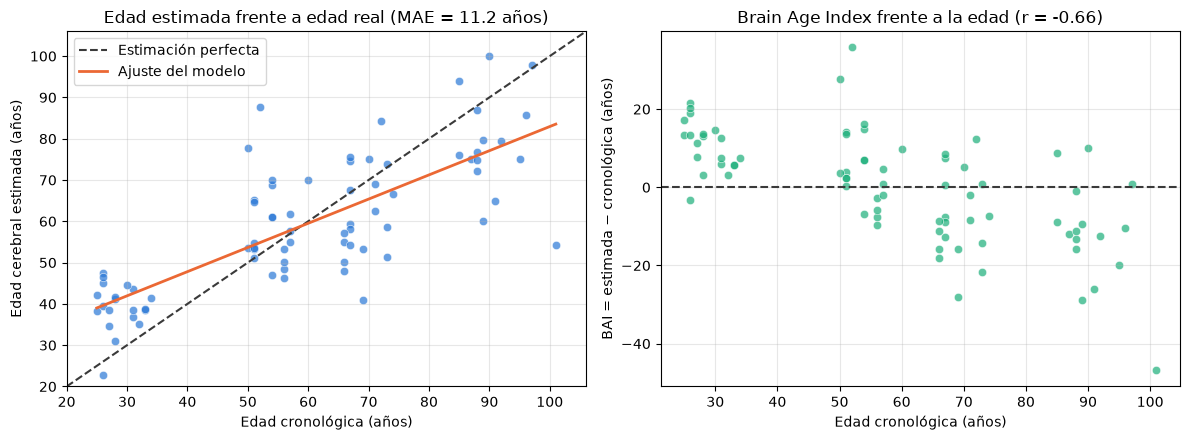

In [13]:
fig, ejes = plt.subplots(1, 2, figsize=(12, 4.5))

limites = [y.min() - 5, y.max() + 5]
ejes[0].scatter(y, prediccion, alpha=0.7, color="#2a78d6", edgecolor="white", linewidth=0.5)
ejes[0].plot(limites, limites, "--", color="#3a3a3a", linewidth=1.5, label="Estimación perfecta")
ejes[0].plot(sorted(y), np.polyval(np.polyfit(y, prediccion, 1), sorted(y)),
             color="#eb6834", linewidth=2, label="Ajuste del modelo")
ejes[0].set(xlabel="Edad cronológica (años)", ylabel="Edad cerebral estimada (años)",
            title=f"Edad estimada frente a edad real (MAE = {mae:.1f} años)",
            xlim=limites, ylim=limites)
ejes[0].legend()

bai = prediccion - y
ejes[1].scatter(y, bai, alpha=0.7, color="#1baf7a", edgecolor="white", linewidth=0.5)
ejes[1].axhline(0, color="#3a3a3a", linestyle="--", linewidth=1.5)
ejes[1].set(xlabel="Edad cronológica (años)", ylabel="BAI = estimada − cronológica (años)",
            title=f"Brain Age Index frente a la edad (r = {stats.pearsonr(y, bai)[0]:+.2f})")

[eje.grid(alpha=0.3) for eje in ejes]
plt.tight_layout()
plt.show()

## 5.1 El Brain Age Index y su sesgo

El panel derecho revela un fenómeno bien documentado en la literatura de edad cerebral: el BAI
presenta correlación negativa con la edad cronológica. El modelo comprime sus estimaciones hacia la
media, de modo que sobreestima a los sujetos jóvenes y subestima a los mayores (regresión a la media).

Esto tiene una consecuencia directa para el sistema final: **si se priorizan sujetos por BAI sin
corregir, se estaría priorizando sistemáticamente a los jóvenes**. La corrección habitual consiste en
ajustar una recta del BAI sobre la edad y quedarse con el residuo.

BAI sin corregir  - correlación con la edad: -0.655
BAI corregido     - correlación con la edad: +0.000

Desviación típica del BAI corregido: 10.5 años

Sujetos con mayor divergencia positiva (cerebro 'mayor' que su edad):
 subject  edad_real  edad_estimada  bai  bai_corregido
      37         52           87.8 35.8           32.9
      23         50           77.8 27.8           24.2
      76         90          100.0 10.0           22.9
      64         85           93.9  8.9           19.7
      56         72           84.4 12.4           17.8

Sujetos con mayor divergencia negativa (cerebro 'menor' que su edad):
 subject  edad_real  edad_estimada   bai  bai_corregido
      61        101           54.2 -46.8          -29.4
      42         69           41.1 -27.9          -23.7
       3         26           22.7  -3.3          -16.9
      60         89           60.2 -28.8          -16.4
      43         73           51.4 -21.6          -15.8


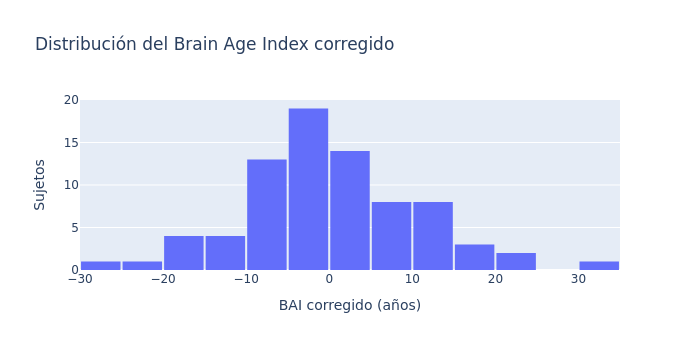

In [14]:
pendiente, intercepto = np.polyfit(y, bai, 1)
bai_corregido = bai - (pendiente * y + intercepto)

divergencia = pd.DataFrame({"subject": datos["subject"], "edad_real": y,
                            "edad_estimada": prediccion.round(1),
                            "bai": bai.round(1), "bai_corregido": bai_corregido.round(1)})

print(f"BAI sin corregir  - correlación con la edad: {stats.pearsonr(y, bai)[0]:+.3f}")
print(f"BAI corregido     - correlación con la edad: {stats.pearsonr(y, bai_corregido)[0]:+.3f}")
print(f"\nDesviación típica del BAI corregido: {bai_corregido.std():.1f} años\n")

print("Sujetos con mayor divergencia positiva (cerebro 'mayor' que su edad):")
print(divergencia.nlargest(5, "bai_corregido").to_string(index=False))
print("\nSujetos con mayor divergencia negativa (cerebro 'menor' que su edad):")
print(divergencia.nsmallest(5, "bai_corregido").to_string(index=False))

px.histogram(divergencia, x="bai_corregido", nbins=25,
             title="Distribución del Brain Age Index corregido",
             labels={"bai_corregido": "BAI corregido (años)"}
             ).update_layout(height=350, yaxis_title="Sujetos", bargap=0.05).show()

# 6. Hallazgos

**Sobre la variable objetivo**

- Se dispone de 78 edades entre 25 y 101 años, no de 153 000 etiquetas como en la clasificación de
  estadios. El tamaño de muestra efectivo es el número de sujetos, y condiciona toda decisión
  posterior: modelos sencillos, validación cruzada agrupada y prudencia con la complejidad.
- Las dos noches de un mismo sujeto no son independientes. Toda partición debe hacerse por sujeto.

**Sobre los datos**

- Los registros duran alrededor de 20 horas por ser ambulatorios; el periodo de sueño ocupa solo una
  fracción. Cualquier característica calculada sobre el registro completo mide mayoritariamente
  vigilia diurna y carece de validez.
- Restringir el cálculo espectral a épocas NREM elimina esa contaminación y homogeneiza la comparación
  entre sujetos.

**Sobre la señal**

- Tanto la arquitectura del sueño como el contenido espectral del canal Fpz-Cz varían con la edad.
- El cambio espectral tiene dos componentes distinguibles: una reducción de la amplitud global y un
  cambio en la forma relativa del espectro, particularmente en la banda de los husos de sueño.

**Sobre la viabilidad**

- Un modelo lineal regularizado sobre estas características, validado por sujeto, estima la edad con
  un error notablemente inferior al de predecir siempre la media, lo que respalda el planteamiento del
  micro-proyecto.
- El BAI sin corregir presenta correlación negativa con la edad cronológica por regresión a la media.
  Si el sistema final prioriza sujetos por divergencia, debe usar el **BAI corregido**; de lo
  contrario priorizaría sistemáticamente a los sujetos jóvenes.

**Siguientes pasos**

- Ampliar el conjunto de características (potencia por estadio, no solo NREM agregado; medidas de
  complejidad; asimetría espectral).
- Comparar el modelo lineal con alternativas no lineales, manteniendo la validación agrupada por
  sujeto.
- Incorporar la corrección del BAI en la lógica de priorización del tablero.